In [67]:
# Diabetes Progression Prediction

In [4]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [66]:
#TASK 1   Import Required Libraries & Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [2]:
diabetes = load_diabetes()
print(diabetes.DESCR)
print("Feature Names:")
print(diabetes.feature_names)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

In [4]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 442
Number of columns: 11


In [7]:
feature_description = {
    "age": "Age",
    "sex": "Sex",
    "bmi": "Body Mass Index",
    "bp": "Blood Pressure",
    "s1": "Blood Serum Measurement 1",
    "s2": "Blood Serum Measurement 2",
    "s3": "Blood Serum Measurement 3",
    "s4": "Blood Serum Measurement 4",
    "s5": "Blood Serum Measurement 5",
    "s6": "Blood Serum Measurement 6",
    "target": "Disease Progression Score"
}

for feature, description in feature_description.items():
    print(f"{feature}: {description}")

age: Age
sex: Sex
bmi: Body Mass Index
bp: Blood Pressure
s1: Blood Serum Measurement 1
s2: Blood Serum Measurement 2
s3: Blood Serum Measurement 3
s4: Blood Serum Measurement 4
s5: Blood Serum Measurement 5
s6: Blood Serum Measurement 6
target: Disease Progression Score


In [8]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [9]:
print("Missing Values:")
print(df.isnull().sum())
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
Total missing values: 0


In [10]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
print("Statistical Summary:")
display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [64]:
#TASK 2  Exploratory Data Analysis

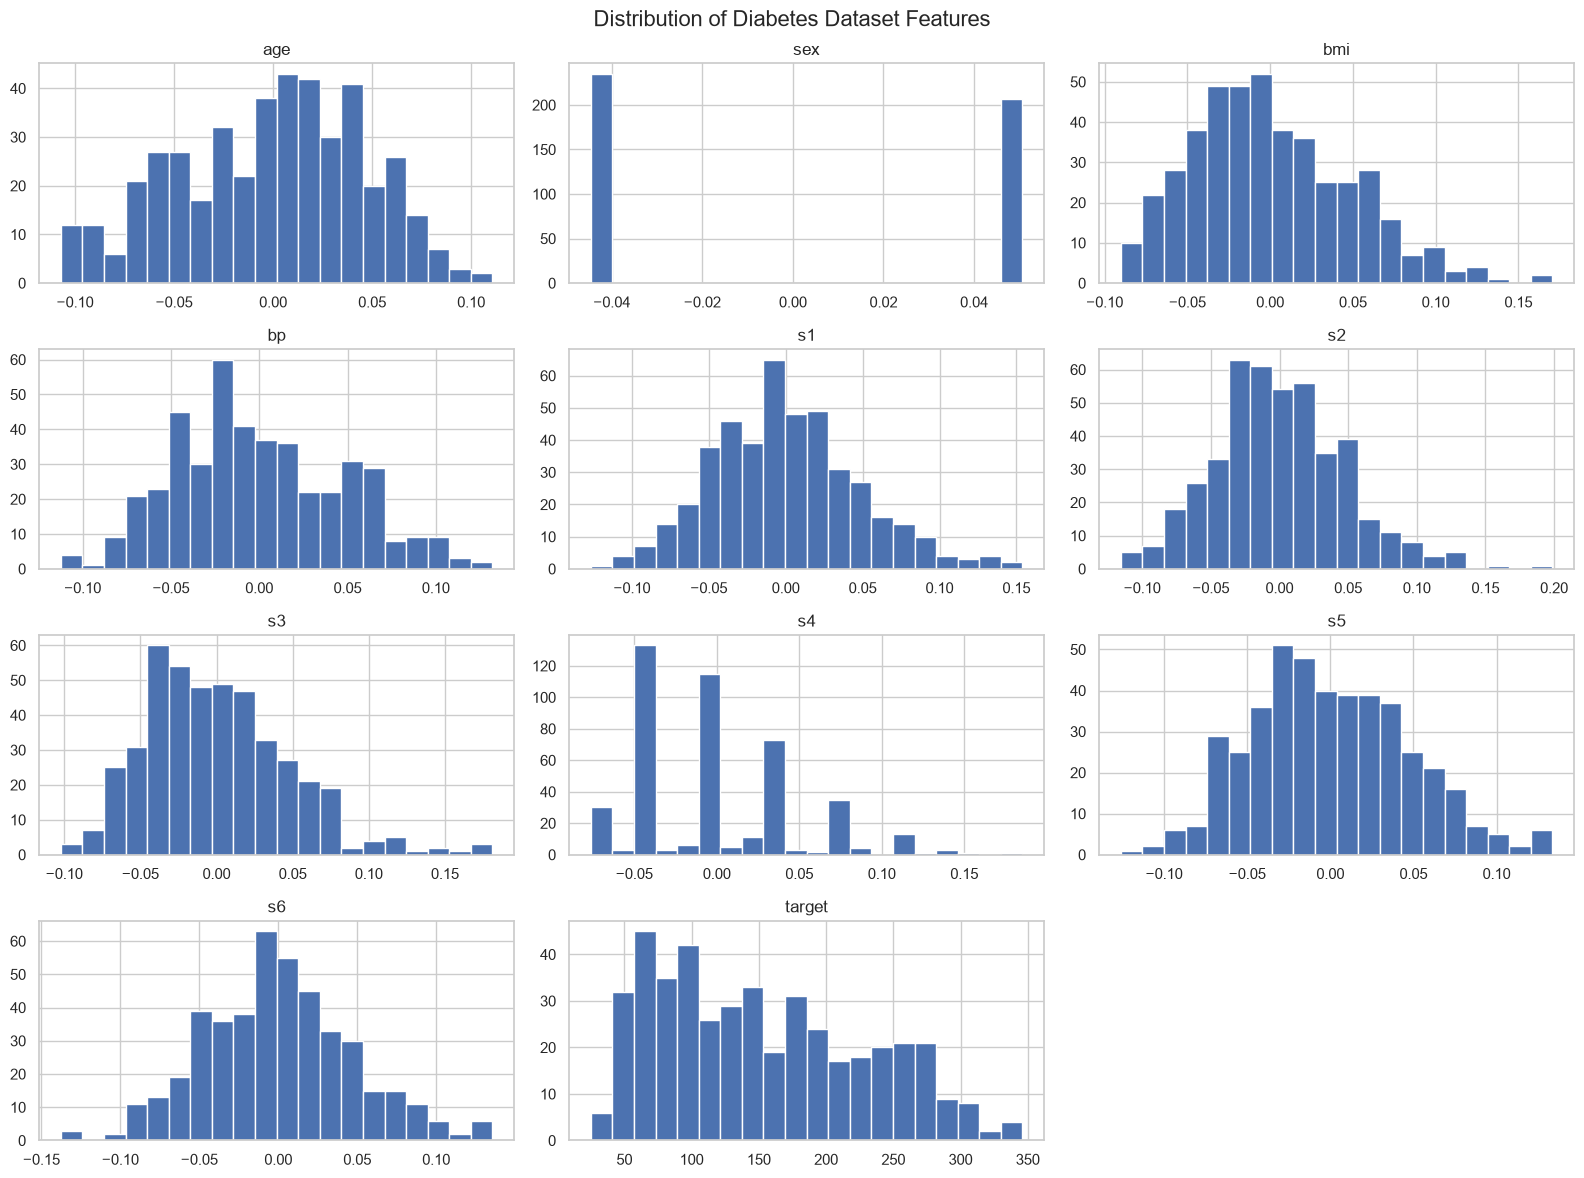

In [12]:
df.hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Diabetes Dataset Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

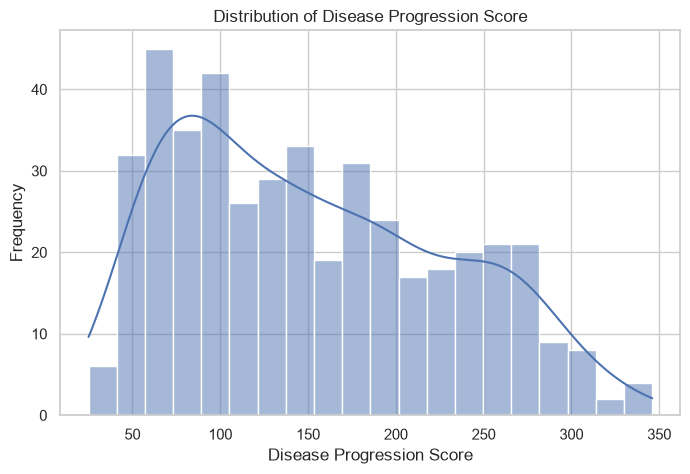

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["target"],
    bins=20,
    kde=True
)

plt.title("Distribution of Disease Progression Score")
plt.xlabel("Disease Progression Score")
plt.ylabel("Frequency")

plt.show()

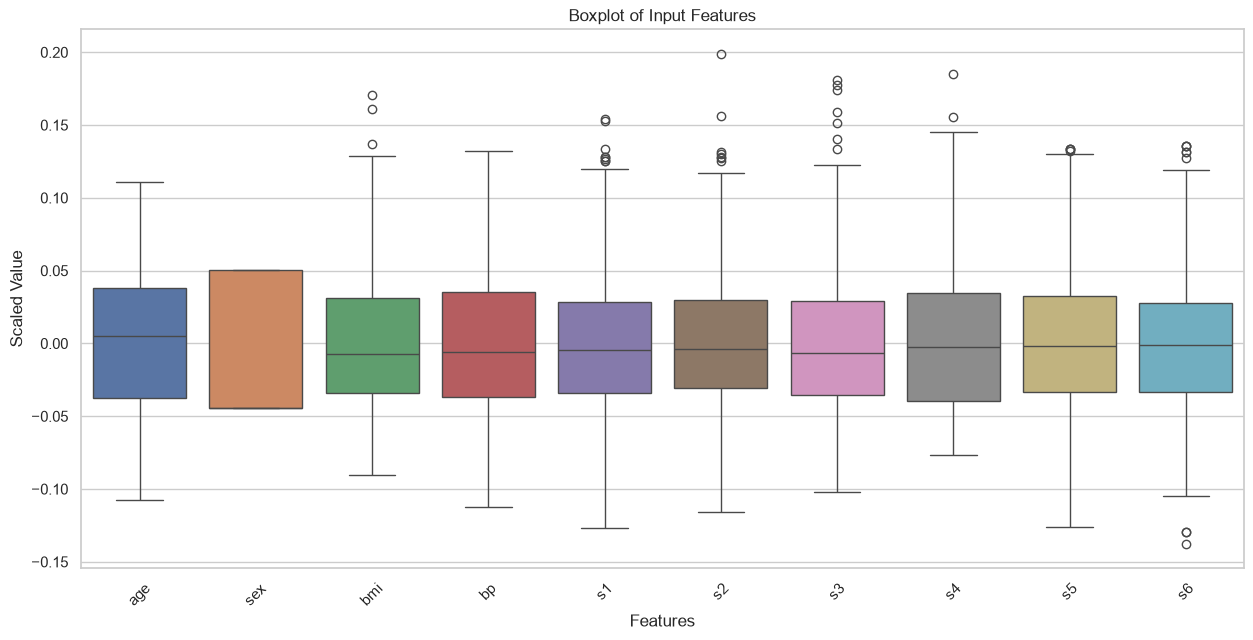

In [14]:
plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df.drop(columns=["target"])
)

plt.title("Boxplot of Input Features")
plt.xlabel("Features")
plt.ylabel("Scaled Value")

plt.xticks(rotation=45)

plt.show()

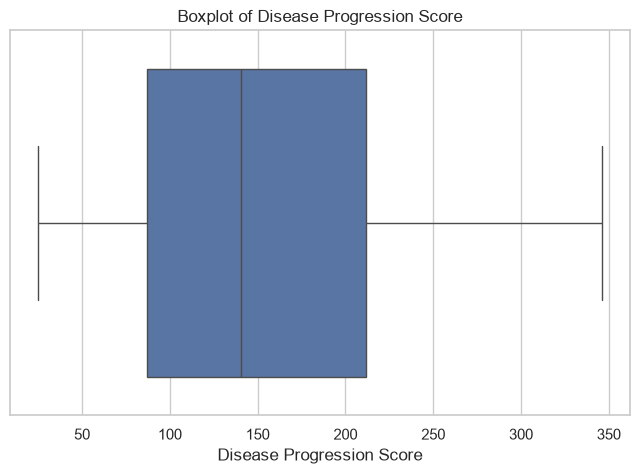

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["target"]
)

plt.title("Boxplot of Disease Progression Score")
plt.xlabel("Disease Progression Score")

plt.show()

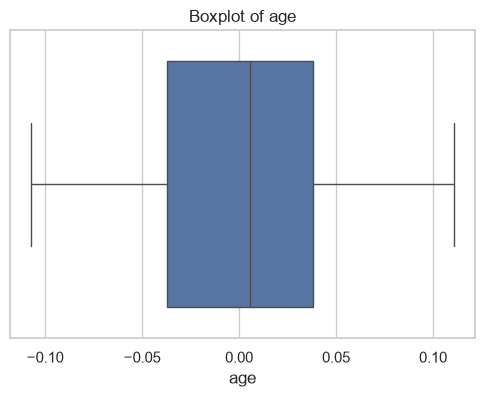

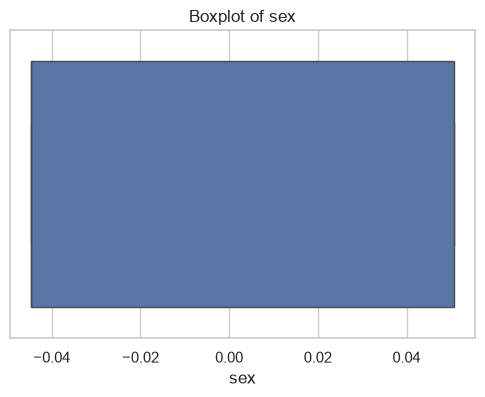

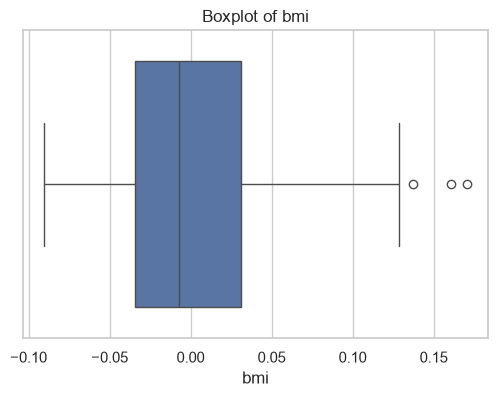

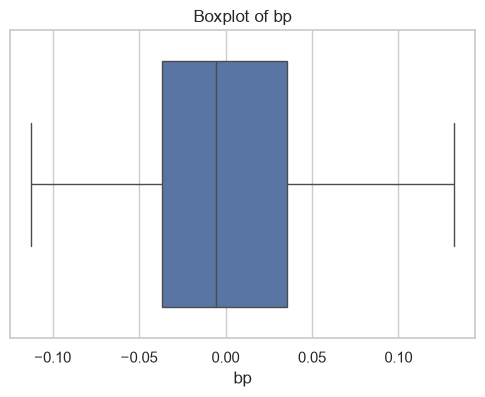

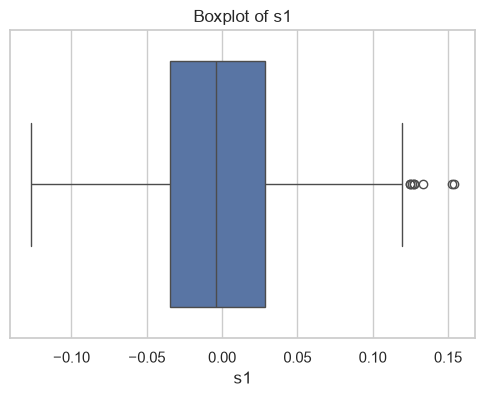

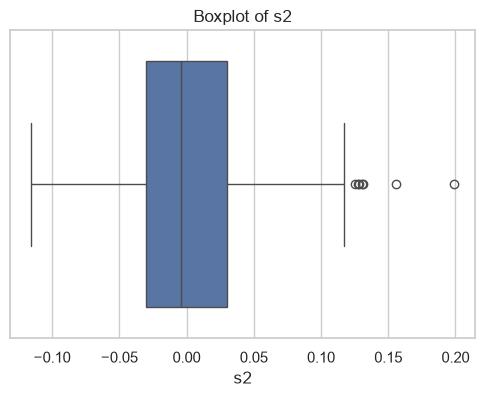

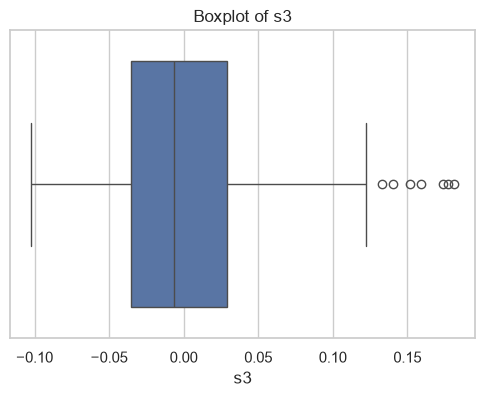

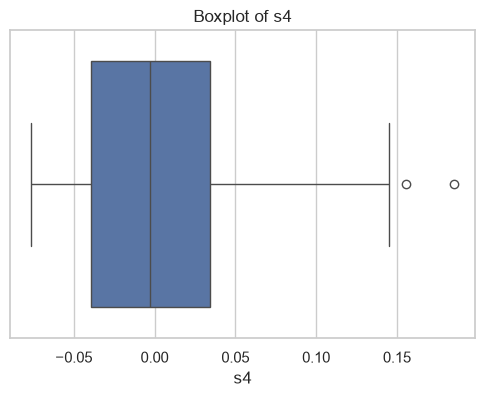

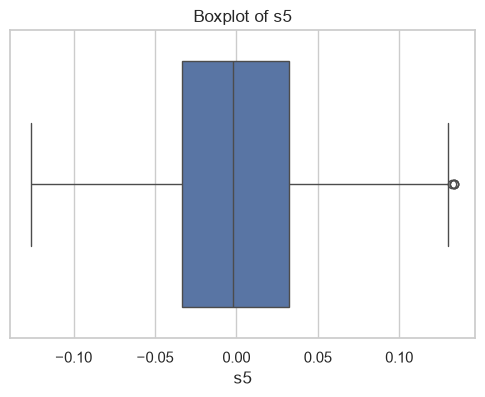

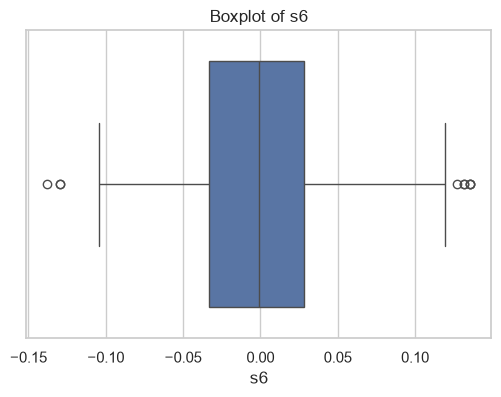

In [16]:
features = diabetes.feature_names

for feature in features:

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.show()

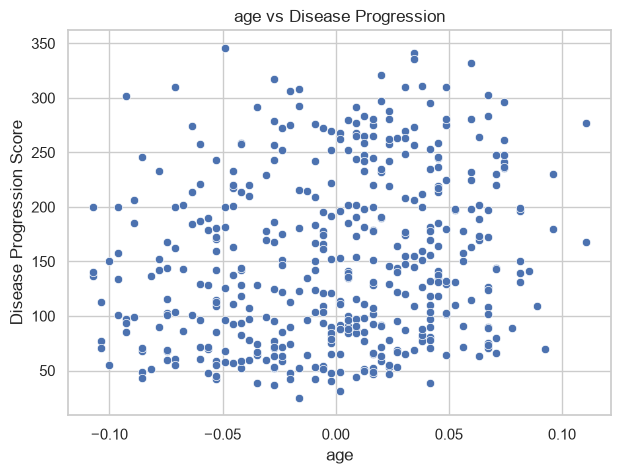

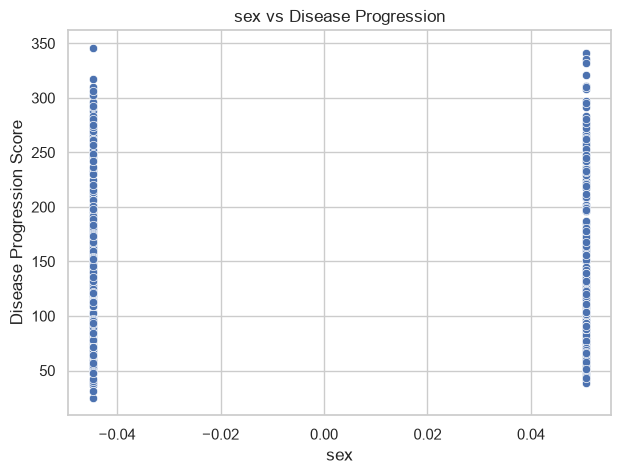

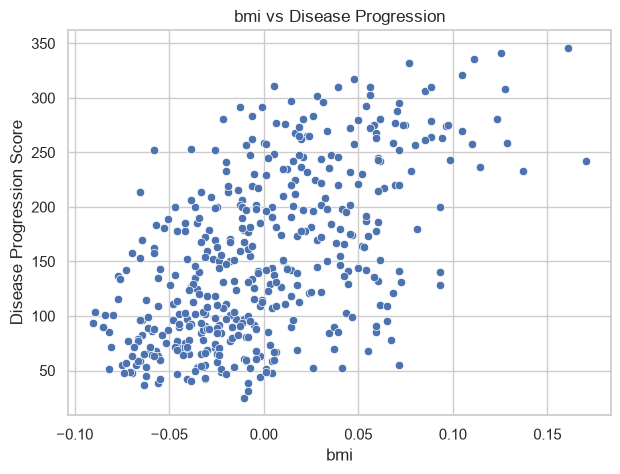

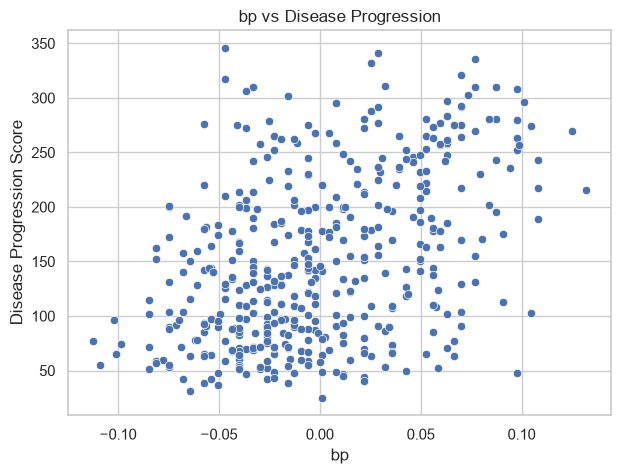

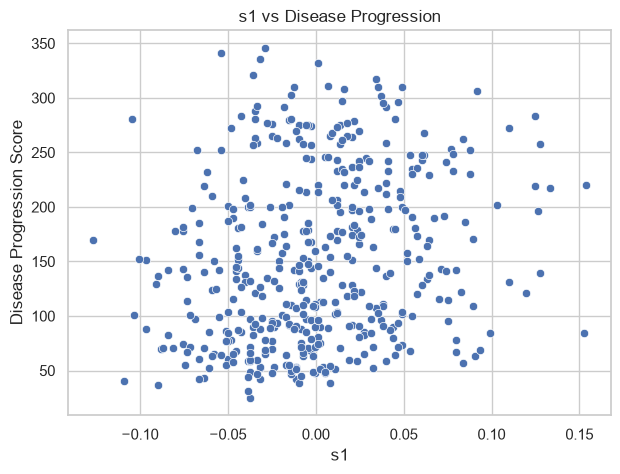

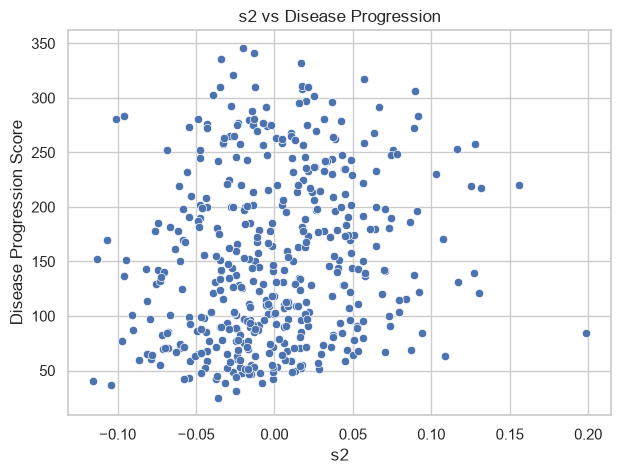

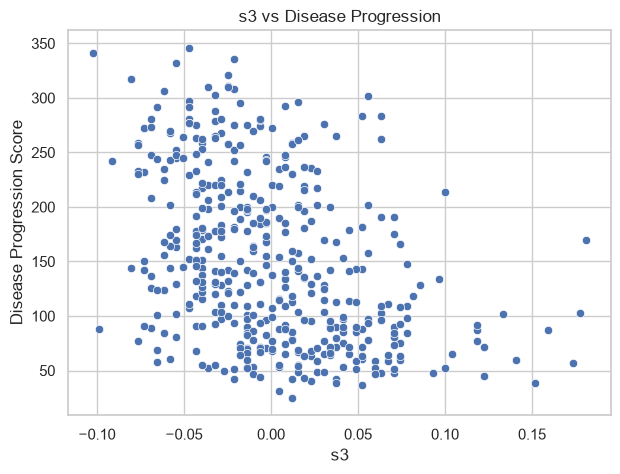

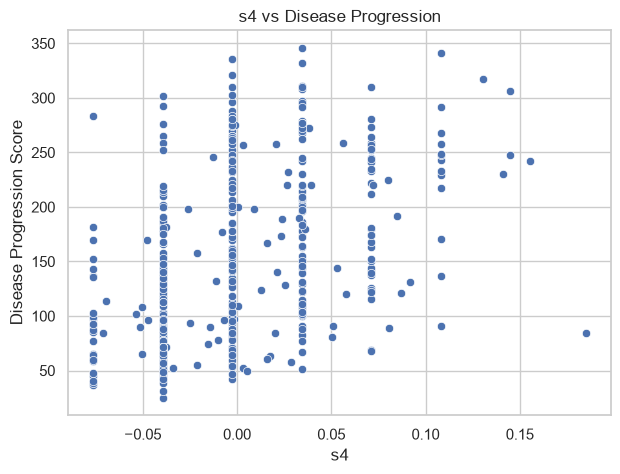

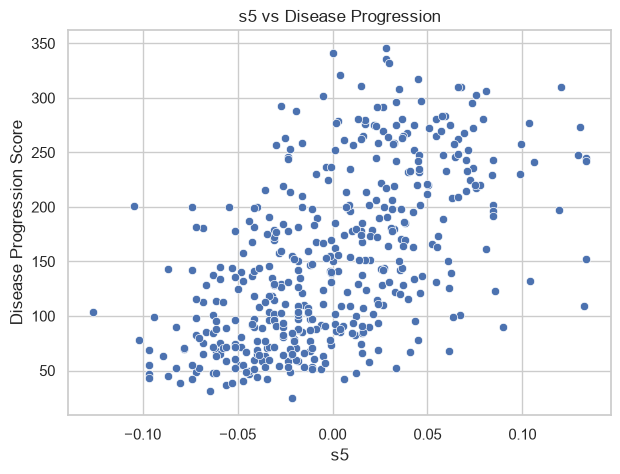

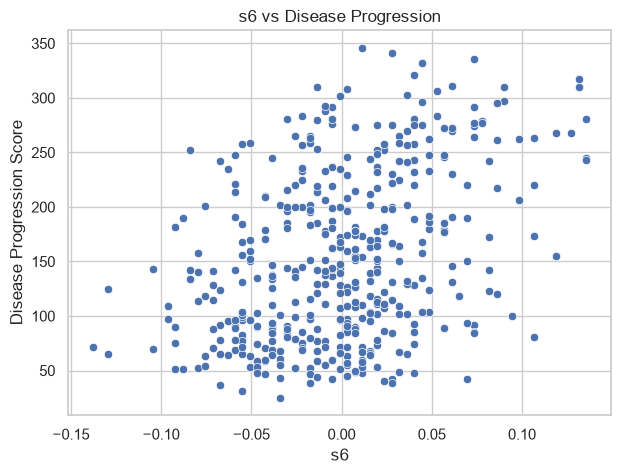

In [17]:
features = diabetes.feature_names

for feature in features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        x=df[feature],
        y=df["target"]
    )

    plt.title(
        f"{feature} vs Disease Progression"
    )

    plt.xlabel(feature)
    plt.ylabel("Disease Progression Score")

    plt.show()

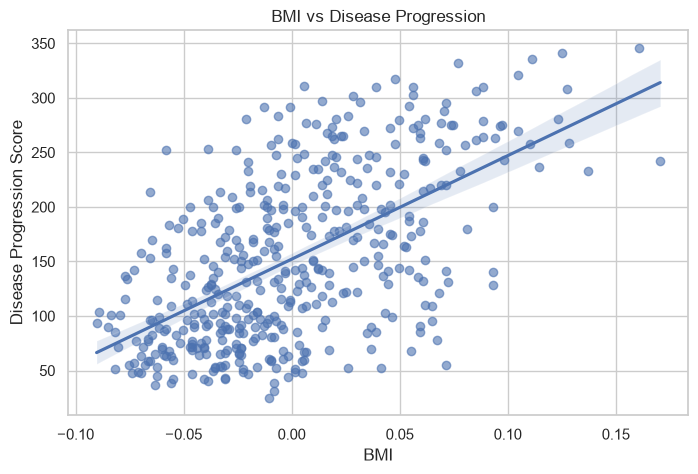

In [18]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x=df["bmi"],
    y=df["target"],
    scatter_kws={"alpha": 0.6}
)

plt.title("BMI vs Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression Score")

plt.show()

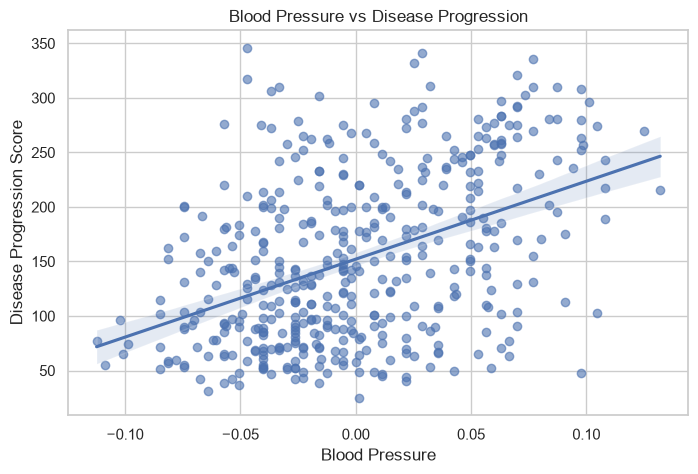

In [19]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x=df["bp"],
    y=df["target"],
    scatter_kws={"alpha": 0.6}
)

plt.title("Blood Pressure vs Disease Progression")
plt.xlabel("Blood Pressure")
plt.ylabel("Disease Progression Score")

plt.show()

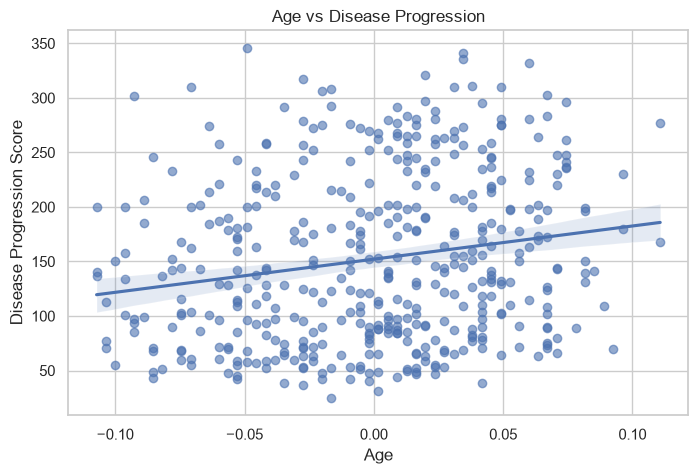

In [20]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x=df["age"],
    y=df["target"],
    scatter_kws={"alpha": 0.6}
)

plt.title("Age vs Disease Progression")
plt.xlabel("Age")
plt.ylabel("Disease Progression Score")

plt.show()

In [63]:
#TASK 3  Feature Correlation

In [22]:
correlation_matrix = df.corr()
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


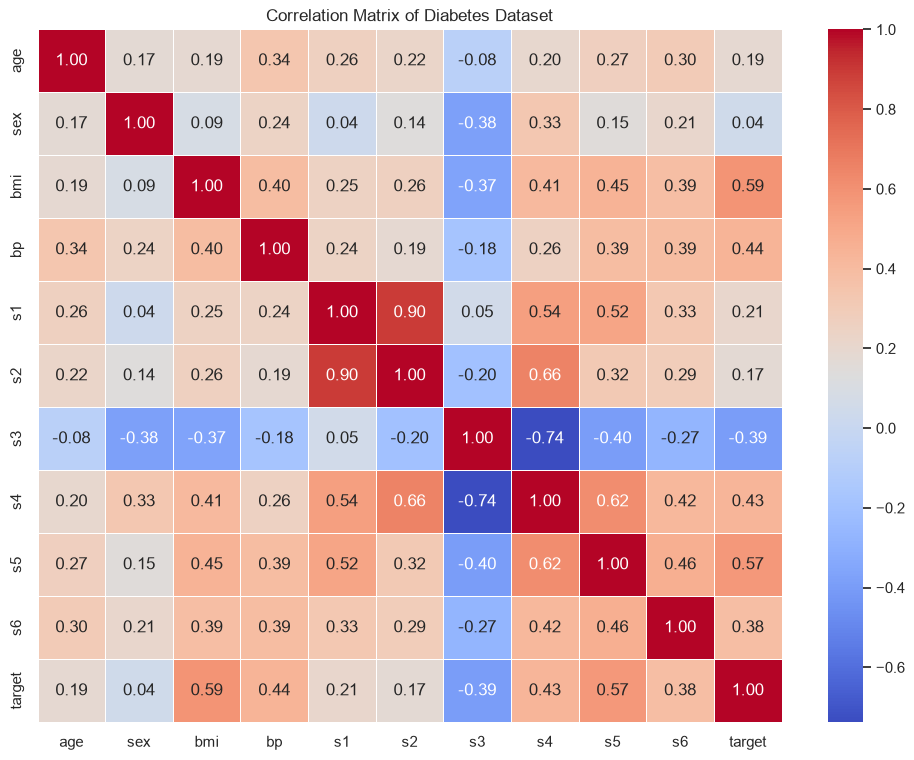

In [23]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Diabetes Dataset")

plt.show()

In [24]:
target_correlation = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values(ascending=False)
)

print("Correlation of Features with Target:")
display(target_correlation)

Correlation of Features with Target:


bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

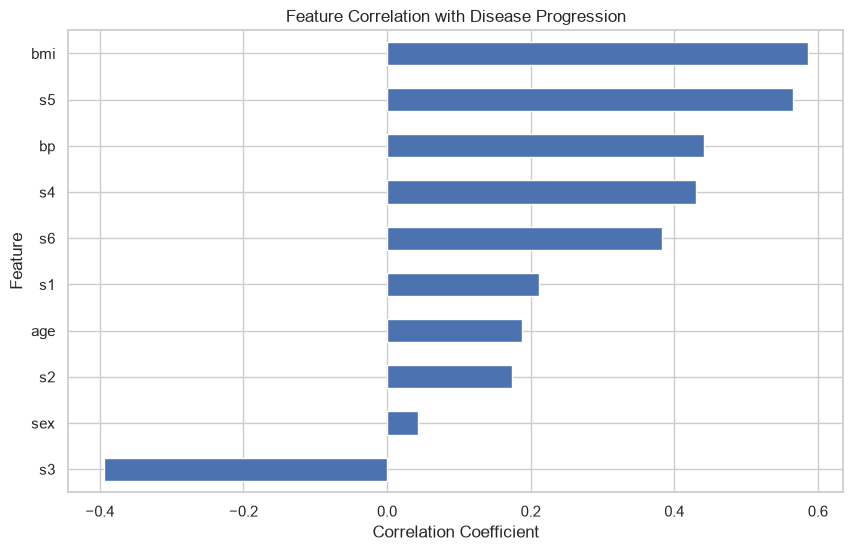

In [32]:
plt.figure(figsize=(10, 6))

target_correlation.sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Disease Progression")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

In [62]:
#TASK 4  Train Linear Regression Model

In [26]:
X = df.drop(columns=["target"])
y = df["target"]
print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features Shape: (442, 10)
Target Shape: (442,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [28]:
model = LinearRegression()
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 37.9 ,-241.96, 542.43,..., 275.32, 736.2 , 48.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [29]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

Intercept:
151.34560453985995

Coefficients:
[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


In [30]:
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(coefficient_df)

,Feature,Coefficient,Absolute_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


In [61]:
#TASK 5 Model Evaluation

In [34]:
y_pred = model.predict(X_test)
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [35]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_df["Error"] = (
    comparison_df["Actual"]
    - comparison_df["Predicted"]
)

display(comparison_df.head(10))

,Actual,Predicted,Error
0,219.0,139.547558,79.452442
1,70.0,179.517208,-109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,-61.417029
4,111.0,123.789659,-12.789659
5,84.0,92.172347,-8.172347
6,242.0,258.232389,-16.232389
7,272.0,181.337321,90.662679
8,94.0,90.224113,3.775887
9,96.0,108.633759,-12.633759


In [36]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.4526027629719196


In [37]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 42.79409467959994


In [38]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 53.85344583676592


In [39]:
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

MODEL EVALUATION
R² Score  : 0.4526
MAE       : 42.7941
RMSE      : 53.8534


In [60]:
#TASK 6 Identify Most Influential Features

In [41]:
coefficient_df

,Feature,Coefficient,Absolute_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


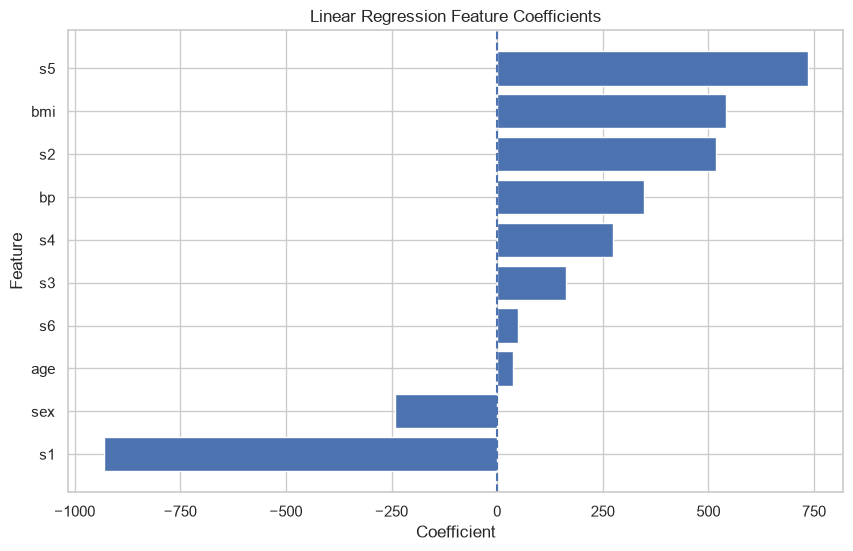

In [42]:
plot_df = coefficient_df.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [43]:
influence_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(
    influence_df[
        ["Feature", "Coefficient", "Absolute_Coefficient"]
    ]
)

,Feature,Coefficient,Absolute_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


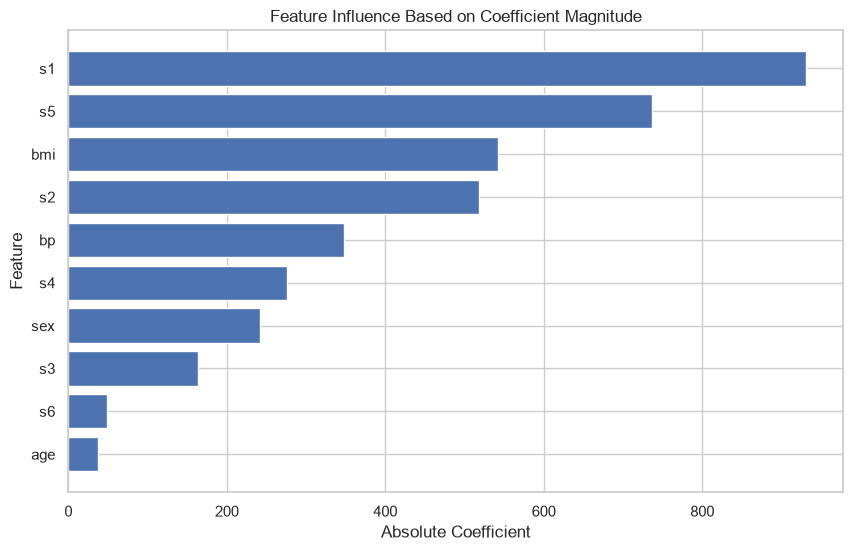

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    influence_df["Feature"],
    influence_df["Absolute_Coefficient"]
)

plt.gca().invert_yaxis()

plt.title("Feature Influence Based on Coefficient Magnitude")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

In [45]:
print("Features ranked by influence:")
print()

for i, row in influence_df.iterrows():

    print(
        f"{row['Feature']:>5} : "
        f"Coefficient = {row['Coefficient']:.4f}"
    )

Features ranked by influence:

   s1 : Coefficient = -931.4888
   s5 : Coefficient = 736.1989
  bmi : Coefficient = 542.4288
   s2 : Coefficient = 518.0623
   bp : Coefficient = 347.7038
   s4 : Coefficient = 275.3179
  sex : Coefficient = -241.9644
   s3 : Coefficient = 163.4200
   s6 : Coefficient = 48.6707
  age : Coefficient = 37.9040


In [46]:
feature_analysis = pd.DataFrame({
    "Correlation_with_Target": correlation_matrix[
        "target"
    ].drop("target"),

    "Regression_Coefficient": model.coef_
})

feature_analysis[
    "Absolute_Coefficient"
] = feature_analysis[
    "Regression_Coefficient"
].abs()

feature_analysis = feature_analysis.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(feature_analysis)

,Correlation_with_Target,Regression_Coefficient,Absolute_Coefficient
s1,0.212022,-931.488846,931.488846
s5,0.565883,736.198859,736.198859
bmi,0.586450,542.428759,542.428759
s2,0.174054,518.062277,518.062277
bp,0.441482,347.703844,347.703844
s4,0.430453,275.317902,275.317902
sex,0.043062,-241.964362,241.964362
s3,-0.394789,163.419983,163.419983
s6,0.382483,48.670657,48.670657
age,0.187889,37.904021,37.904021


In [59]:
#TASK 7 Compare Actual vs Predicted Values

In [48]:
comparison_df = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": y_pred
})

comparison_df["Absolute Error"] = (
    abs(
        comparison_df["Actual Value"]
        - comparison_df["Predicted Value"]
    )
)

display(comparison_df.head(20))

,Actual Value,Predicted Value,Absolute Error
0,219.0,139.547558,79.452442
1,70.0,179.517208,109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,61.417029
4,111.0,123.789659,12.789659
5,84.0,92.172347,8.172347
6,242.0,258.232389,16.232389
7,272.0,181.337321,90.662679
8,94.0,90.224113,3.775887
9,96.0,108.633759,12.633759


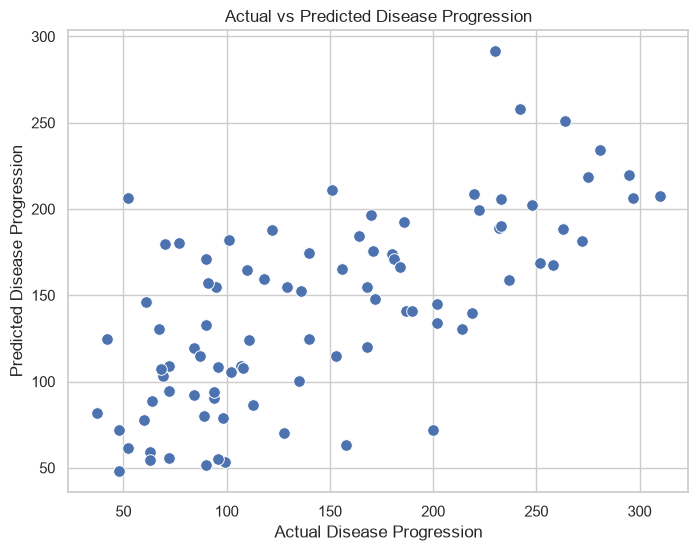

In [49]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    s=70
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")

plt.title("Actual vs Predicted Disease Progression")

plt.show()

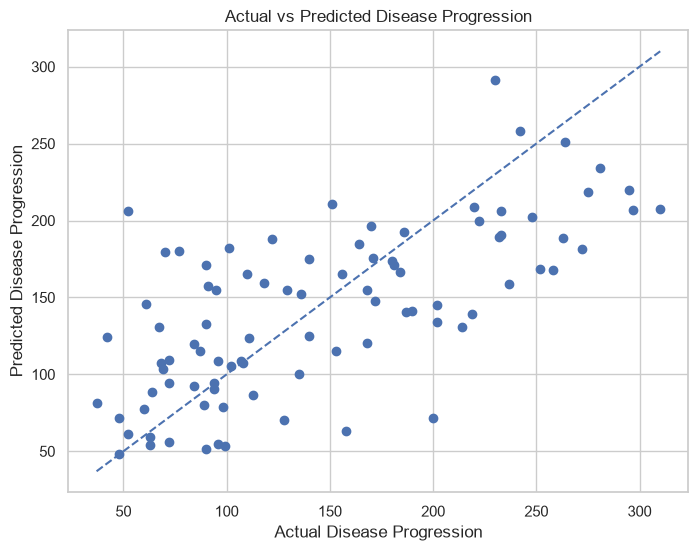

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")

plt.title(
    "Actual vs Predicted Disease Progression"
)

plt.show()

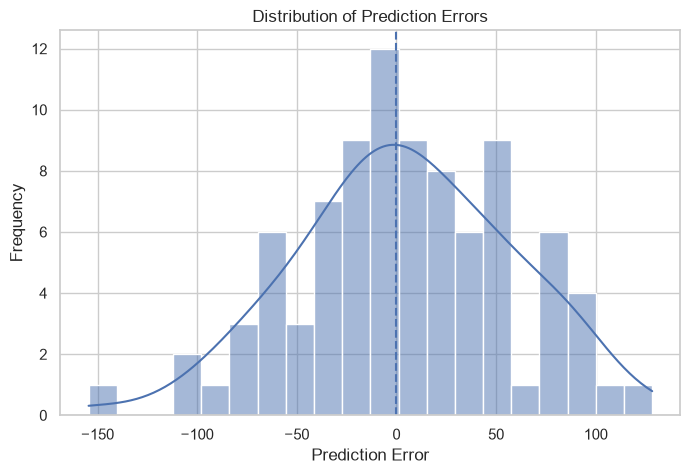

In [51]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(
    errors,
    bins=20,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

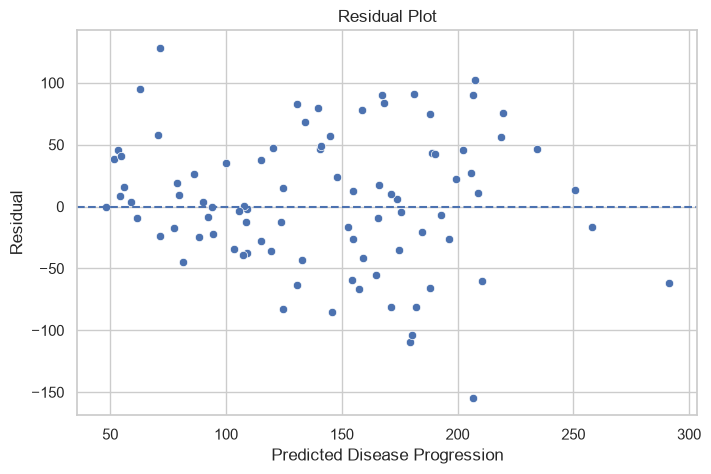

In [52]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=errors
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Disease Progression")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [53]:
mean_error = errors.mean()

print(
    f"Mean Prediction Error: {mean_error:.4f}"
)

Mean Prediction Error: 3.9128


In [54]:
max_error = errors.abs().max()

print(
    f"Maximum Absolute Prediction Error: {max_error:.4f}"
)

Maximum Absolute Prediction Error: 154.4934


In [55]:
print("=" * 60)
print("DIABETES PROGRESSION PREDICTION - FINAL RESULTS")
print("=" * 60)

print(f"Dataset Size       : {df.shape[0]} samples")
print(f"Number of Features : {X.shape[1]}")
print(f"Training Samples   : {X_train.shape[0]}")
print(f"Testing Samples    : {X_test.shape[0]}")

print("\nModel:")
print("Linear Regression")

print("\nEvaluation Metrics:")
print(f"R² Score           : {r2:.4f}")
print(f"MAE                : {mae:.4f}")
print(f"RMSE               : {rmse:.4f}")

DIABETES PROGRESSION PREDICTION - FINAL RESULTS
Dataset Size       : 442 samples
Number of Features : 10
Training Samples   : 353
Testing Samples    : 89

Model:
Linear Regression

Evaluation Metrics:
R² Score           : 0.4526
MAE                : 42.7941
RMSE               : 53.8534


In [56]:
comparison_df.to_csv(
    "diabetes_predictions.csv",
    index=False
)

print(
    "Predictions saved as diabetes_predictions.csv"
)

Predictions saved as diabetes_predictions.csv


In [57]:
feature_analysis.to_csv(
    "feature_analysis.csv"
)

print(
    "Feature analysis saved as feature_analysis.csv"
)

Feature analysis saved as feature_analysis.csv


In [58]:
print("=" * 60)
print("Structural Flow")
print("=" * 60)
#  Diabetes Progression Prediction
#  │
#  ├── 1. Import Libraries
#  │
#  ├── 2. Load Dataset
#  │
#  ├── 3. Dataset Overview
#  │   ├── Shape
#  │   ├── Features
#  │   ├── Data Types
#  │   ├── Missing Values
#  │   └── Duplicates
#  │
#  ├── 4. Exploratory Data Analysis
#  │   ├── Statistical Summary
#  │   ├── Histograms
#  │   ├── Target Distribution
#  │   ├── Boxplots
#  │   └── Scatterplots
#  │
#  ├── 5. Correlation Analysis
#  │   ├── Correlation Matrix
#  │   ├── Heatmap
#  │   └── Target Correlations
#  │
#  ├── 6. Data Preparation
#  │   ├── X
#  │   ├── y
#  │   └── Train/Test Split
#  │
#  ├── 7. Linear Regression
#  │   ├── Create Model
#  │   ├── Train Model
#  │   └── Coefficients
#  │
#  ├── 8. Model Evaluation
#  │   ├── R²
#  │   ├── MAE
#  │   └── RMSE
#  │
#  ├── 9. Feature Influence
#  │   ├── Coefficient Table
#  │   └── Feature Influence Plot
#  │
#  ├── 10. Actual vs Predicted
#  │   ├── Comparison Table
#  │   ├── Scatter Plot
#  │   └── Perfect Prediction Line
#  │
#  └── 11. Residual Analysis
#      ├── Error Distribution
#      └── Residual Plot

Structural Flow
